In [3]:
# Load dataframe

import pandas as pd
import matplotlib.pyplot as plt

divers = pd.read_csv('deepest-diving-animals.csv')
divers

,animal,category,depth
0,Emperor Penguin,penguins,564
1,King Penguin,penguins,343
2,Rockhopper Penguin,penguins,104
3,Macaroni Penguin,penguins,154
4,Royal Penguin,penguins,226
...,...,...,...
113,Northern Sea Otter,sea otters,97
114,Southern Sea Otter,sea otters,88
115,Atlantic Walrus,walruses,500
116,Dugong,other marine mammals,33


In [4]:
# Count categories

divers['category'].value_counts()

category
other seabirds          45
seals                   24
penguins                14
toothed whales          14
baleen whales            7
sea lions                5
turtles                  4
sea otters               2
other marine mammals     2
walruses                 1
Name: count, dtype: int64

In [5]:
# Calculate max depth by category using groupby()

max_depths = divers.groupby('category') ['depth'].max()
max_depths

category
baleen whales            616
other marine mammals      33
other seabirds           152
penguins                 564
sea lions                597
sea otters                97
seals                   2389
toothed whales          2992
turtles                 1344
walruses                 500
Name: depth, dtype: int64

In [6]:
# Use reset_index() to turn above series into a two column dataframe

df = max_depths.reset_index(name='max_depth')
df

,category,max_depth
0,baleen whales,616
1,other marine mammals,33
2,other seabirds,152
3,penguins,564
4,sea lions,597
5,sea otters,97
6,seals,2389
7,toothed whales,2992
8,turtles,1344
9,walruses,500


Text(0, 0.5, 'Maximum Depth (meters)')

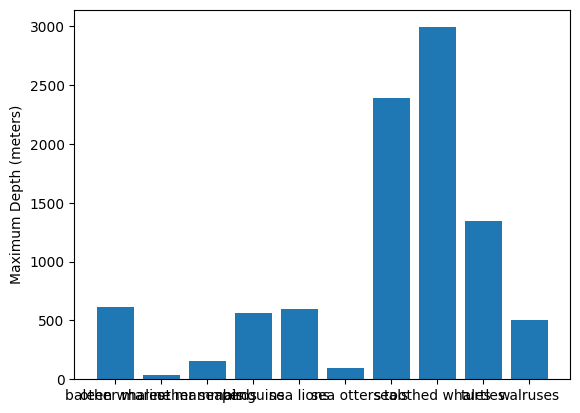

In [11]:
plt.bar(df['category'], df['max_depth'])
plt.ylabel('Maximum Depth (meters)')

Text(0.5, 0, 'Maximum Depth (meters)')

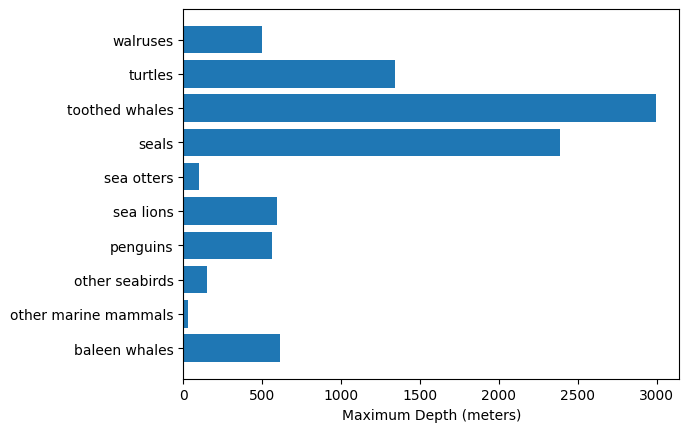

In [7]:
# Pro tips 1; to fix overlapping category - Horizontal bar plot

plt.barh(df['category'], df['max_depth'])
plt.xlabel('Maximum Depth (meters)')

In [8]:
# Pro tips 2; give thr bars order

df = df.sort_values('max_depth')
df

,category,max_depth
1,other marine mammals,33
5,sea otters,97
2,other seabirds,152
9,walruses,500
3,penguins,564
4,sea lions,597
0,baleen whales,616
8,turtles,1344
6,seals,2389
7,toothed whales,2992


# Rerun to get a sorted graph

plt.barh(df['category'], df['max_depth'])
plt.xlabel('Maximum Depth (meters)')

def clean_bar_axes():
    ax = plt.gca() # get current axis
    ax.spines[['top','bottom','left','right']].set_visible(False)
    ax.grid(axis='x', color='black', alpha=0.5)
    ax.tick_params(axis='both', length=0)

In [9]:
# Pro tips 3; swap ticks and spines for faded grid
# Python function to apply in any bar chart

def clean_bar_axes():
    ax = plt.gca() # get current axis
    ax.spines[['top','bottom','left','right']].set_visible(False)
    ax.grid(axis='x', color='black', alpha=0.5)
    ax.tick_params(axis='both', length=0)

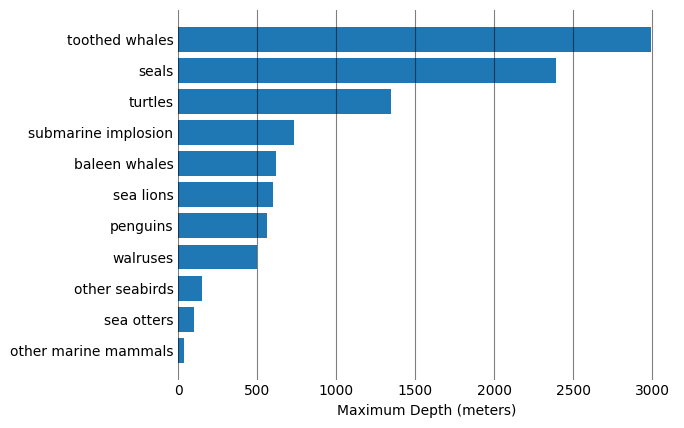

In [24]:
# Visual Storytelling
plt.barh(df['category'], df['max_depth'])
plt.xlabel('Maximum Depth (meters)')
clean_bar_axes()

In [35]:
# Add a color column to control colors in a graph

df['color'] = 'C0'
df

,category,max_depth,color
1,other marine mammals,33,C0
5,sea otters,97,C0
2,other seabirds,152,C0
9,walruses,500,C0
3,penguins,564,C0
4,sea lions,597,C0
0,baleen whales,616,C0
ref_0,submarine implosion,730,C0
8,turtles,1344,C0
6,seals,2389,C0


In [36]:
# CO is the first color in the tab10 color palette supported by Matplotlib
# Add a reference row for the "Submarine Implosion" depth of 730 meters using color C1
# Locate rows by index using the df.loc[] notation - This allows the adding of new rows

df.loc['ref_0'] = ['submarine implosion', 730, 'C1']
df = df.sort_values('max_depth')
df

,category,max_depth,color
1,other marine mammals,33,C0
5,sea otters,97,C0
2,other seabirds,152,C0
9,walruses,500,C0
3,penguins,564,C0
4,sea lions,597,C0
0,baleen whales,616,C0
ref_0,submarine implosion,730,C1
8,turtles,1344,C0
6,seals,2389,C0


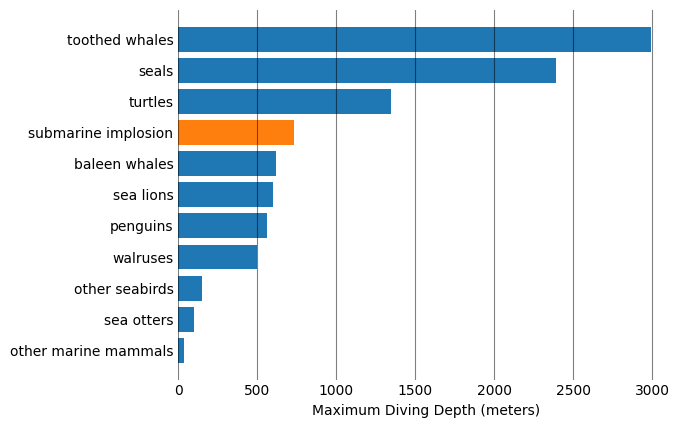

In [37]:
# Plotting with color

plt.barh(df['category'], df['max_depth'], color=df['color'])
plt.xlabel('Maximum Diving Depth (meters)')
clean_bar_axes()